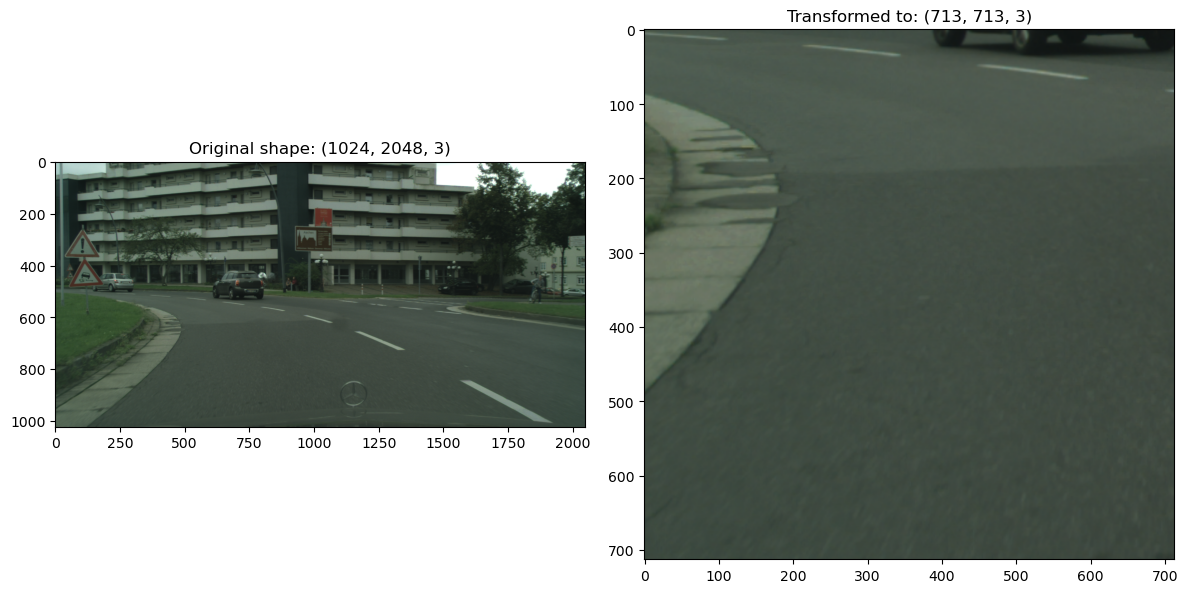

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from util import transform
import collections
import collections.abc as collections_abc
# For backward compatibility with old code
if not hasattr(collections, 'Iterable'):
    collections.Iterable = collections_abc.Iterable

# Parameters from your config
train_h, train_w = 413, 413
scale_min, scale_max = 0.5, 2.0
ignore_label = 255
mean = [0.485 * 255, 0.456 * 255, 0.406 * 255]

# Using the exact same transforms as train.py, but dropping Gaussian blur, ToTensor and Normalize
# so we can easily plot the image.
test_transform = transform.Compose([
    transform.RandScale([scale_min, scale_max]),
    # Optional: transform.RandRotate([-10, 10], padding=mean, ignore_label=ignore_label),
    transform.Crop([train_h, train_w], crop_type='rand', padding=mean, ignore_label=ignore_label)
])

# 1. Provide the path to a test image from your dataset
# For Cityscapes: "semseg/dataset/cityscapes/leftImg8bit/train/aachen/aachen_000000_000019_leftImg8bit.png"
# For VOC2012: "semseg/dataset/VOC2012/JPEGImages/2007_000032.jpg"
image_path = "../semseg/dataset/cityscapes/leftImg8bit/train/aachen/aachen_000000_000019_leftImg8bit.png" # Update this path!

# Load image
image = cv2.imread(image_path, cv2.IMREAD_COLOR)
if image is None:
    raise FileNotFoundError(f"Could not load image at {image_path}")

image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Create a dummy label array of the same size (transformations expect image and label)
label = np.zeros(image.shape[:2], dtype=np.uint8)

# 2. Apply the transform
cropped_img, _ = test_transform(image, label)

# 3. Visualize Original vs Cropped
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title(f"Original shape: {image.shape}")
plt.imshow(image)

plt.subplot(1, 2, 2)
plt.title(f"Transformed to: {cropped_img.shape}")
plt.imshow(cropped_img)

plt.tight_layout()
plt.show()